In [64]:
import brainpy as bp
import brainpy.math as bm
import numpy as np
import matplotlib.pyplot as plt

In [147]:
class CorticalNeuron(bp.dyn.NeuDyn):
    def __init__(self, size, C=0.25, g_L=16.7, V_L=-70., V_th=-50.,
                 V_reset=-60., tau_ref=4., V_initializer=None, method='exp_auto'):
        super().__init__(size=size)

        # Parameters
        self.C = C                    # Capacitance (nF)
        self.g_L = g_L                # Leak conductance (nS)
        self.V_L = V_L                # Leak reversal potential (mV)
        self.V_th = V_th              # Spike threshold (mV)
        self.V_reset = V_reset        # Reset potential (mV)
        self.tau_ref = tau_ref        # Refractory period (ms)

        # Variables
        if V_initializer is None:
            self.V = bm.Variable(bm.ones(self.num) * V_L)
        else:
            self.V = bp.init.variable_(V_initializer, self.num)
        self.spike = bm.Variable(bm.zeros(self.num, dtype=bool))
        self.refractory = bm.Variable(bm.zeros(self.num, dtype=bool))
        self.t_last_spike = bm.Variable(bm.ones(self.num) * -1e7)
        self.input = bm.Variable(bm.zeros(self.num))

        # Integrator
        self.integral = bp.odeint(self.dV_dt, method=method)

    def dV_dt(self, V, t, I_total):
        dVdt = (-self.g_L * (V - self.V_L) + I_total) / self.C # I_total includes adaptation and other synaptic inputs, as well as external input
        return dVdt

    def update(self, x=None):
        t = bp.share['t']
        dt = bp.share['dt']
        x = 0. if x is None else x  # External input

        # Total input current from other neurons, and adaptation
        I_total = self.input + x #

        # Refractory check
        refractory = (t - self.t_last_spike) <= self.tau_ref
        V = self.integral(self.V.value, t, I_total, dt=dt) # Add the linear part of the dynamics
        V = bm.where(refractory, self.V.value, V)

        # Spike generation
        spike = V >= self.V_th
        self.spike.value = spike
        self.t_last_spike.value = bm.where(spike, t, self.t_last_spike.value)
        self.V.value = bm.where(spike, self.V_reset, V)
        self.refractory.value = bm.logical_or(refractory, spike)

        # Reset input
        self.input[:] = 0.


In [206]:
class ExcitatoryNeuron(CorticalNeuron):
    def __init__(self, size, V_K=-85., tau_K=80., delta_g_K=10., **kwargs):
        super().__init__(size=size, **kwargs)

        # Adaptation parameters
        self.V_K = V_K                  # Potassium reversal potential (mV)
        self.tau_K = tau_K              # Adaptation time constant (ms)
        self.delta_g_K = delta_g_K      # Conductance increment (nS)

        # Variables
        self.g_K = bm.Variable(bm.zeros(self.num))  # Adaptation conductance
        self.I_K = bm.Variable(bm.zeros(self.num))  # Adaptation current

        # Integrator for adaptation conductance
        self.g_K_integral = bp.odeint(self.dg_K_dt, method=kwargs.get('method', 'exp_auto'))

    def dg_K_dt(self, g_K, t):
        return -g_K / self.tau_K

    def update(self, x=None):
        t = bp.share['t']
        dt = bp.share['dt']
        x = 0. if x is None else x  # External input

        # Update adaptation conductance
        g_K = self.g_K_integral(self.g_K.value, t, dt=dt)
        g_K = bm.where(self.spike.value, g_K + self.delta_g_K, g_K)
        self.g_K.value = g_K

        # Calculate adaptation current
        self.I_K.value = -self.g_K * (self.V.value - self.V_K)

        # Include adaptation current
        self.input += self.I_K

        # Proceed with standard update, passing external input
        super().update(x=x)


In [231]:
class InhibitoryNeuron(CorticalNeuron):
    def __init__(self, size, **kwargs):
        super().__init__(size=size, **kwargs)

    def update(self, x=None):
        # Proceed with standard update
        super().update(x=x)


Predict 20000 steps: : 100%|██████████| 20000/20000 [00:00<00:00, 79904.06it/s]


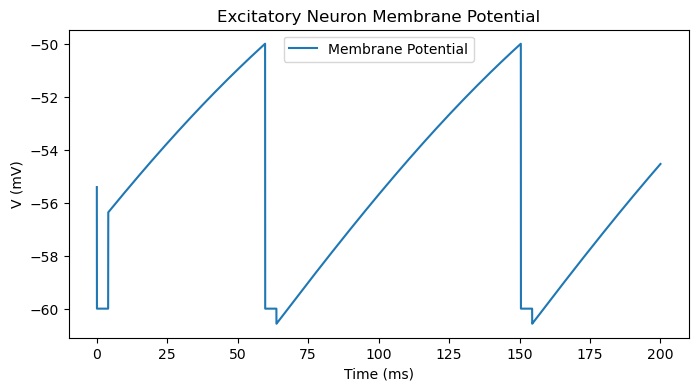

In [258]:
# Test the excitatory neurons
neuron = ExcitatoryNeuron(size=1)
# Set up the runner
runner = bp.DSRunner(
    neuron,
    monitors=['V', 'spike'],
    dt=0.01
)
inputs = np.ones(int(200. / runner.dt)) * 500.  # constant input for 20 ms. 500 pA
runner.run(inputs=inputs)  # Run for 200 ms

# Plot the membrane potential
plt.figure(figsize=(8, 4))
plt.plot(runner.mon.ts, runner.mon.V, label='Membrane Potential')
plt.xlabel('Time (ms)')
plt.ylabel('V (mV)')
plt.title('Excitatory Neuron Membrane Potential')
plt.legend()
# plt.xlim(58, 68)
plt.show()


Predict 2000 steps: : 100%|██████████| 2000/2000 [00:00<00:00, 23338.32it/s]


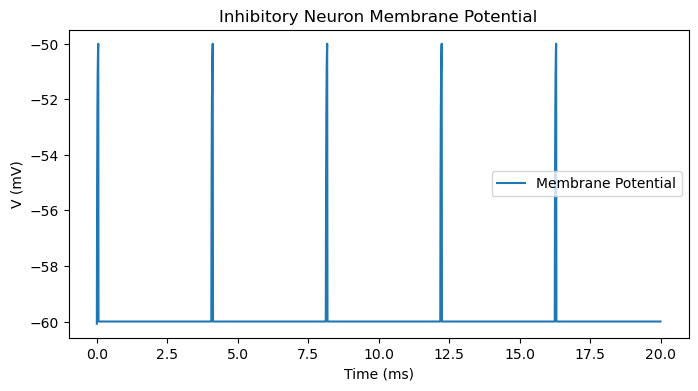

In [270]:
# Test the inhibitory neurons
neuron = InhibitoryNeuron(size=1) # These are the default parameters, but look weird. For constant input, the inhibitory inputs just spike as soon as the refractory period ends
# Set up the runner
runner = bp.DSRunner(
    neuron,
    monitors=['V', 'spike'],
    dt=0.01
)
inputs = np.ones(int(20. / runner.dt)) * 340.  # constant input for 200 ms. 500 pA
runner.run(inputs=inputs)  # Run for 200 ms

# Plot the membrane potential
plt.figure(figsize=(8, 4))
plt.plot(runner.mon.ts, runner.mon.V, label='Membrane Potential')
plt.xlabel('Time (ms)')
plt.ylabel('V (mV)')
plt.title('Inhibitory Neuron Membrane Potential')
plt.legend()
# plt.ylim(-60.5, -58)
plt.show()


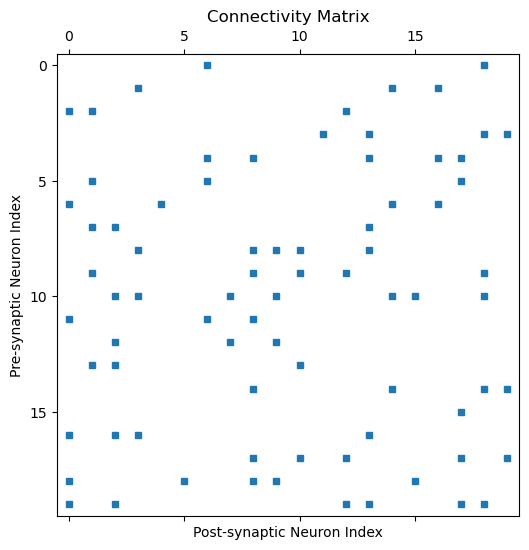

In [365]:
# Test connections

# Create pre and post neuron groups
num_pre = 20
pre = ExcitatoryNeuron(size=num_pre)
post = pre
num_post = post.num

# Generate connections using BrainPy's connector
conn = bp.connect.FixedProb(prob=0.2)

# Generate delays between 0 and 5 ms
delays = bm.random.uniform(0, 5, size=(num_pre, num_post))

# Synaptic parameters
J = 0.5  # Synaptic weight (nS)
E_rev = 0.0  # Reversal potential for excitatory synapses (mV)
tau_d = 5.0  # Decay time constant (ms)
tau_r = 0.1  # Rise time constant (ms)

# Create the synapse
synapse = CorticalSynapse(
    pre=pre,
    post=post,
    conn=conn,
    J=J,
    E_rev=E_rev,
    tau_d=tau_d,
    tau_r=tau_r,
    delay=delays
)
# Plot the connectivity matrix
plt.figure(figsize=(6, 6))
plt.spy(synapse.conn.build_mat(), markersize=5)
plt.title('Connectivity Matrix')
plt.xlabel('Post-synaptic Neuron Index')
plt.ylabel('Pre-synaptic Neuron Index')
plt.show()